# Paired t-tests

Because every single user took the NASA-TLX after Task 1 (Low Load) and again after Task 2 (High Load), their scores are paired. A paired t-test checks if the average difference between these two sets of observations of same user is significantly different from zero.
<br>
<br>
**Null Hypothesis ($H_0$)** : There is no statistically significant difference between the NASA-TLX scores of the two tasks<br>
**Alternate Hypothesis  ($H_1$)** : There is a statisitcally significant difference between the NASA-TLX scores of the two tasks
<br>

- If the p-value < 0.05 we reject the null hypothesis in favor of the alternate hypothesis
- If p-value >= 0.05 the t-test fails and we fail to reject the null hypothesis.

In [14]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import t
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_survey = pd.read_csv('../data_logs/processed/survey_data.csv')

In [4]:
df_grouped = df_survey.groupby('Session_ID').first().reset_index()

In [7]:
df_grouped.head

<bound method NDFrame.head of    Session_ID               Timestamp  A1_Mental  A2_Temporal  A3_Performance  \
0          p1    29/06/2026, 10:31:42         30           30              80   
1         p10  6/29/2026, 11:39:24 AM         20           20              80   
2         p11  6/29/2026, 11:54:39 AM         30            5               5   
3         p12  6/29/2026, 12:00:39 PM         53           50              98   
4         p13   6/29/2026, 4:20:47 PM         20           50               0   
5          p2    29/06/2026, 11:02:25         60           65             100   
6          p3   29/6/2026, 2:00:10 pm          2           69               0   
7          p4  6/29/2026, 12:17:50 PM         18           15              26   
8          p5  6/29/2026, 12:12:45 PM          1            8               7   
9          p6  6/29/2026, 10:09:44 AM         36           13              19   
10         p7  6/27/2026, 10:37:05 PM          7            6             100  

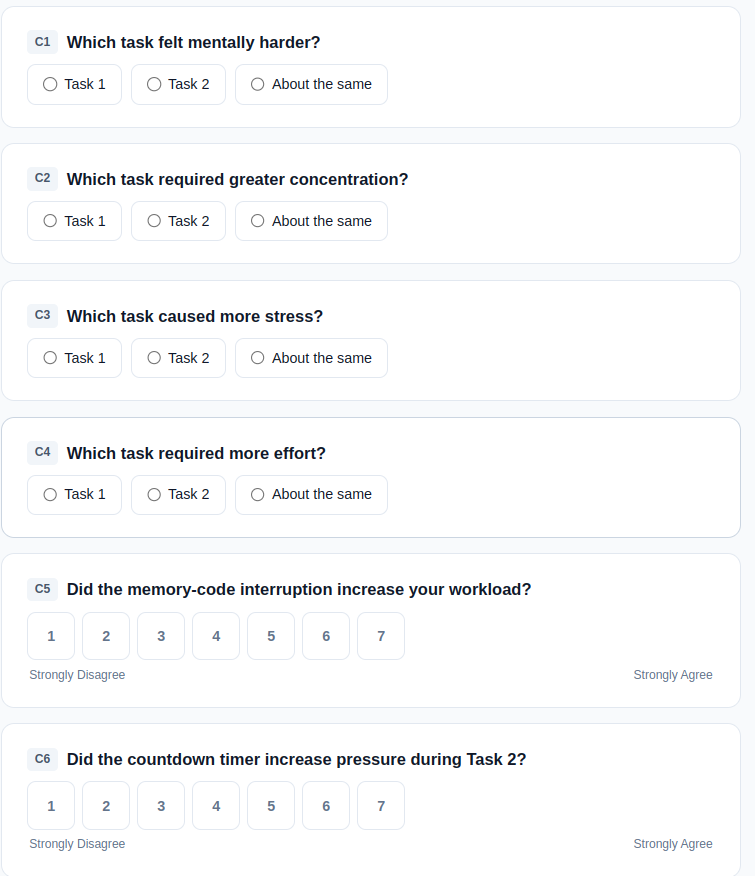

In [9]:
cat_cols = ['C1', 'C2', 'C3', 'C4']

task2_percentages = df_survey[cat_cols].apply(
    lambda col: (col.astype(str).str.strip().str.lower() == 'task 2').mean() * 100
)
print('Percentage of People answered task 2 for the questions C1 through C4: \n')
print(f" Harder (C1):       {task2_percentages['C1']:.1f}%")
print(f" Concentration (C2): {task2_percentages['C2']:.1f}%")
print(f" Stress (C3):        {task2_percentages['C3']:.1f}%")
print(f" Effort (C4):        {task2_percentages['C4']:.1f}%")

Percentage of People answered task 2 for the questions C1 through C4: 

 Harder (C1):       100.0%
 Concentration (C2): 100.0%
 Stress (C3):        92.3%
 Effort (C4):        100.0%


In [10]:
# questions C5 and C6 have answer that are on the likert scale i.e 4 being neutral
num_cols = ['C5', 'C6']

likert_percentages = df_survey[num_cols].apply(pd.to_numeric, errors='coerce').ge(5).mean() * 100

print("\nMechanic-Specific Impact:")
print(f"-> Interruption Workload (C5): {likert_percentages['C5']:.1f}%")
print(f"-> Timer Pressure (C6):        {likert_percentages['C6']:.1f}%")


Mechanic-Specific Impact:
-> Interruption Workload (C5): 76.9%
-> Timer Pressure (C6):        61.5%


In [11]:
task1_scores = df_grouped['Task1_TLX']
task2_scores = df_grouped['Task2_TLX']

t_stat, p_value = stats.ttest_rel(task2_scores, task1_scores)
print('NASA-TLX paired t-test Results: \n')
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value:     {p_value:.4f}")

NASA-TLX paired t-test Results: 

T-Statistic: 5.2728
P-Value:     0.0002


In [12]:
alpha = 0.05

if p_value < alpha:
    print("RESULT: Reject null hypothesis in favor of alternate hypothesis (p < 0.05)")
else:
    print("RESULT: Failure to Reject null hypothesis (p >= 0.05)")
    print("The users found Task 1 and Task 2 to be somewhat similar in difficulty.")

RESULT: Reject null hypothesis in favor of alternate hypothesis (p < 0.05)


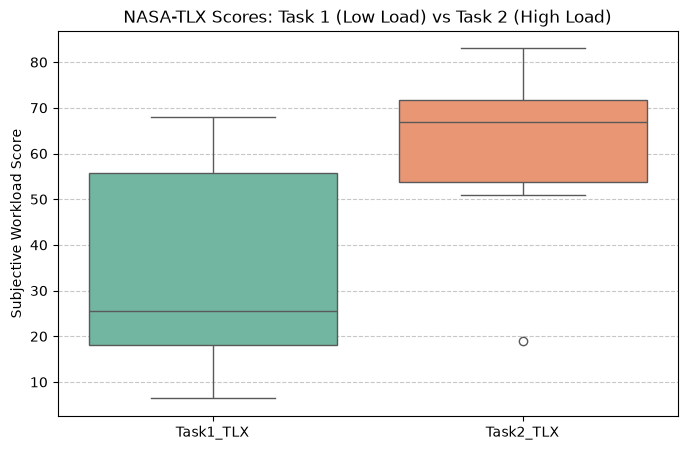

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_grouped[['Task1_TLX', 'Task2_TLX']], palette="Set2")
plt.title("NASA-TLX Scores: Task 1 (Low Load) vs Task 2 (High Load)")
plt.ylabel("Subjective Workload Score")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

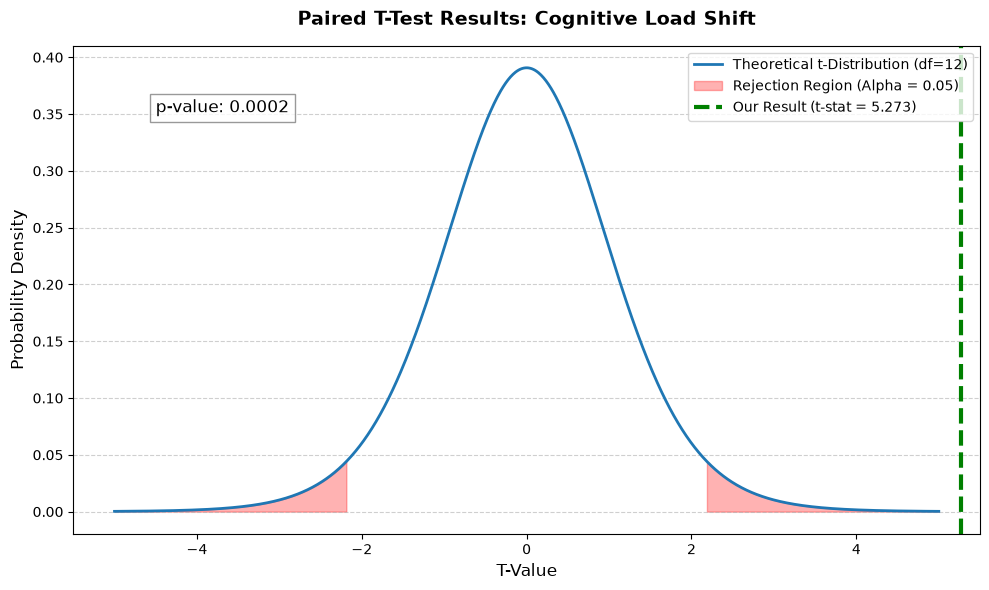

In [16]:
N = len(task1_scores) 
df_dof = N - 1
alpha = 0.05

x = np.linspace(-5, 5, 1000)
y = t.pdf(x, df_dof)

# This finds the exact boundaries where the 5% alpha is split (2.5% on each tail)
t_crit_left = t.ppf(alpha/2, df_dof)
t_crit_right = t.ppf(1 - alpha/2, df_dof)


plt.figure(figsize=(10, 6))
plt.plot(x, y, label=f"Theoretical t-Distribution (df={df_dof})", color='#1f77b4', linewidth=2)
plt.fill_between(x, 0, y, where=(x <= t_crit_left), color='red', alpha=0.3, label='Rejection Region (Alpha = 0.05)')
plt.fill_between(x, 0, y, where=(x >= t_crit_right), color='red', alpha=0.3)
plt.axvline(x=t_stat, color='green', linestyle='--', linewidth=3, label=f'Our Result (t-stat = {t_stat:.3f})')


plt.title("Paired T-Test Results: Cognitive Load Shift", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("T-Value", fontsize=12)
plt.ylabel("Probability Density", fontsize=12)
plt.text(-4.5, max(y)*0.9, f"p-value: {p_value:.4f}", 
         fontsize=12, bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()